Testing trained Resnet18V2 models.

Initializing environment

In [11]:
!pip install git+https://github.com/KarolKutyla/awp_tf_tests.git
from google.colab import drive
drive.mount('/content/drive')

import tensorflow as tf

from awp_tf_tests.datasets.v2 import cifar_10
from awp_tf.attacks.v2.pgd import PGDAttack, PGDParams

from awp_tf_tests.visualisation.draw_attacks_v2 import AdversarialPlots

tf.config.run_functions_eagerly(False)

train_ds, test_ds = cifar_10.load_cifar_dataset()
labels = cifar_10.load_cifar_labels()
steps_per_epoch = train_ds.cardinality()

attack_params = PGDParams(perturbation_bound=128/255, pgd_step=20, pgd_step_size=15/255, norm="l2")

def get_checkpoint_path(model_name):
    return f"/content/drive/MyDrive/checkpoints/{model_name}/epoch_200.keras"

  Cloning https://github.com/KarolKutyla/awp_tf_tests.git to /tmp/pip-req-build-3slhp778
  Running command git clone --filter=blob:none --quiet https://github.com/KarolKutyla/awp_tf_tests.git /tmp/pip-req-build-3slhp778
  Resolved https://github.com/KarolKutyla/awp_tf_tests.git to commit 72baca109b56556fdda7af0290e68c712e17fd24
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Cloning https://github.com/KarolKutyla/awp_tf.git to /tmp/pip-install-rx0ljjjk/awp-tf_886f3212a7b946a9969be0b2d96d883b
  Running command git clone --filter=blob:none --quiet https://github.com/KarolKutyla/awp_tf.git /tmp/pip-install-rx0ljjjk/awp-tf_886f3212a7b946a9969be0b2d96d883b
  Resolved https://github.com/KarolKutyla/awp_tf.git to commit 035ecafb9fface0be31cd2ffe3585fda1e665512
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
Drive alread

Visualizing adversarial examples on single batch from train dataset and evaluating trained model on test dataset

79/79 ━━━━━━━━━━━━━━━━━━━━ 4s 22ms/step - accuracy: 0.8743 - loss: 0.8430
79/79 ━━━━━━━━━━━━━━━━━━━━ 287s 4s/step - accuracy: 0.2243 - loss: 16.0476


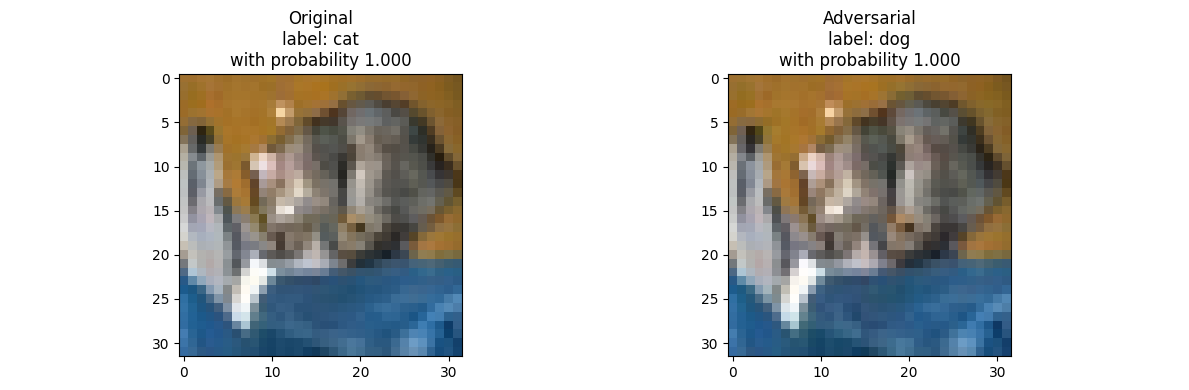

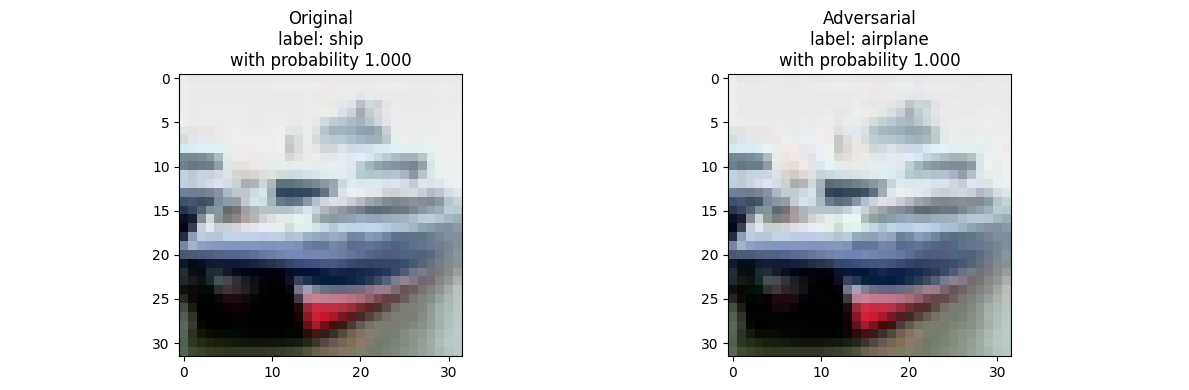

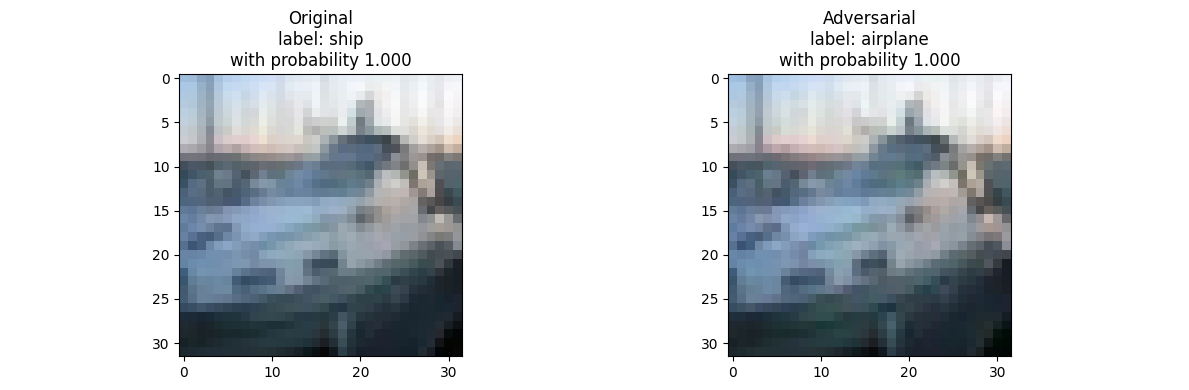

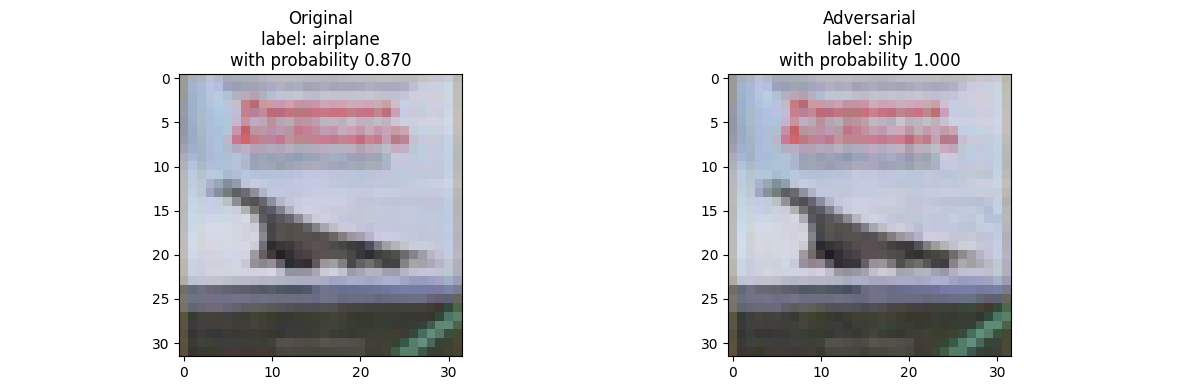

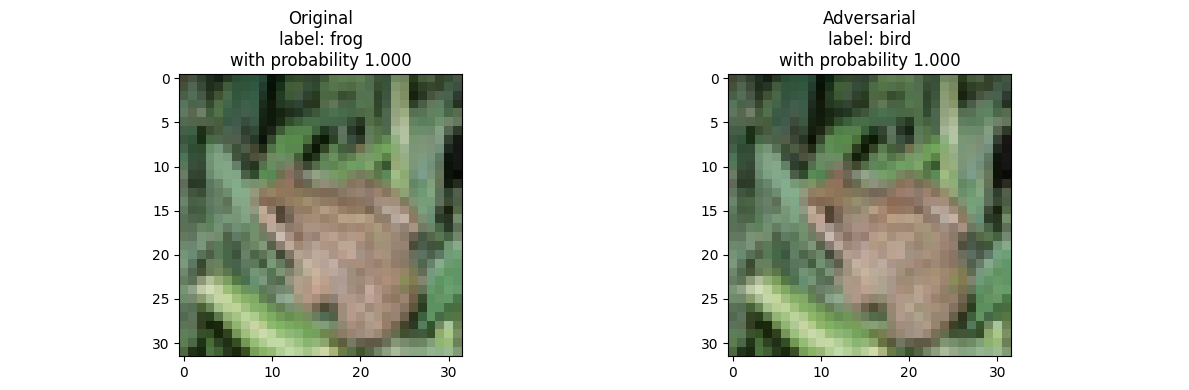

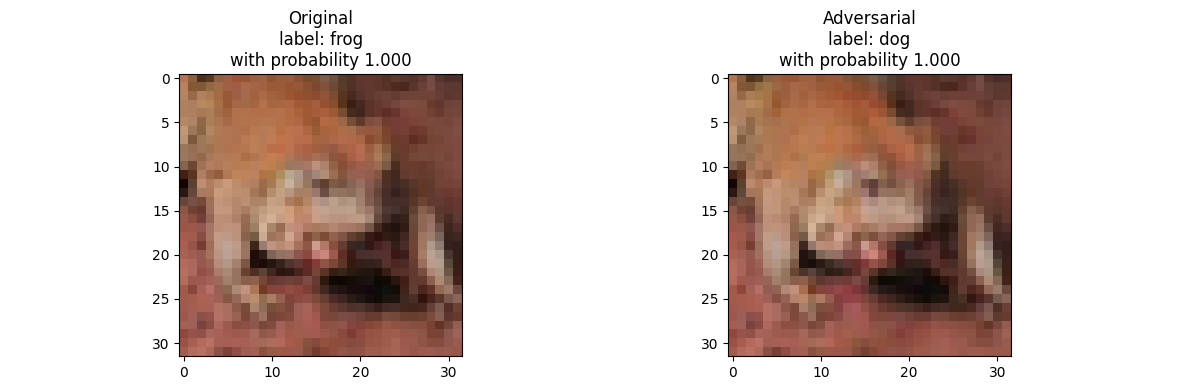

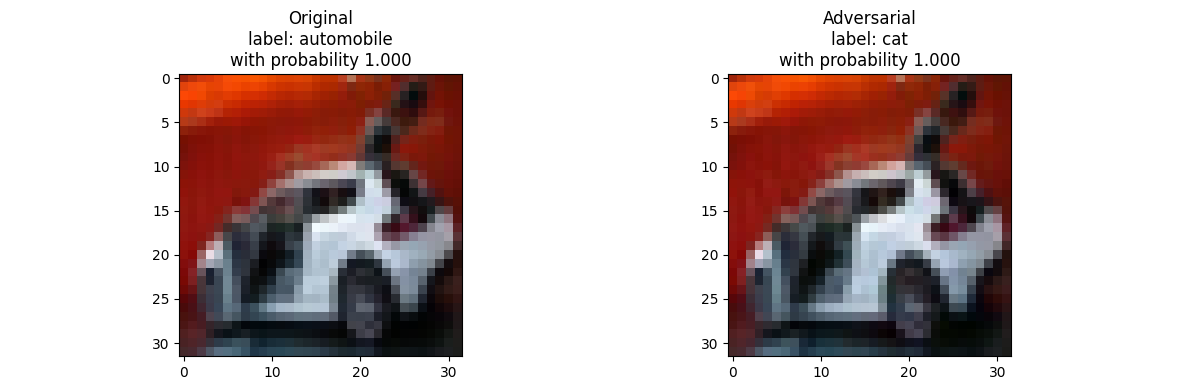

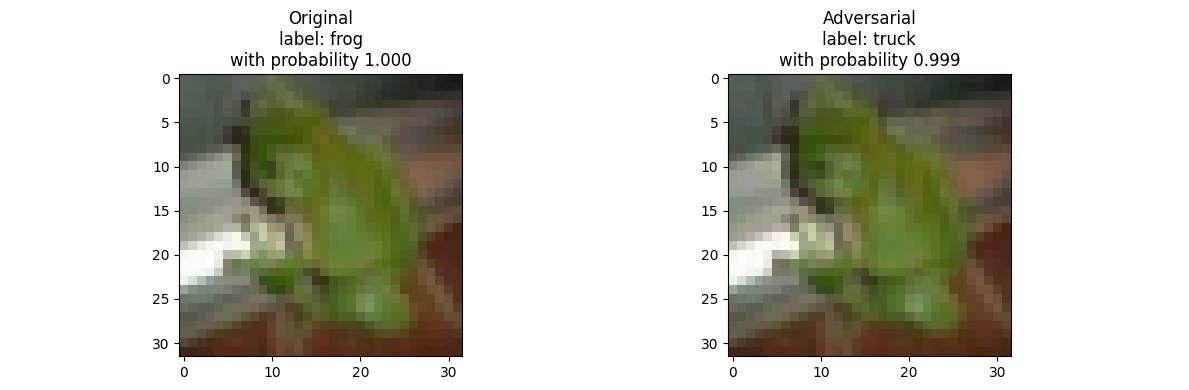

In [41]:
model = tf.keras.models.load_model(get_checkpoint_path("resnet_18v2_normal"))
model.compile(metrics=['accuracy'])
pgd_20 = PGDAttack(model, params=attack_params)
test_ds_attacked = test_ds.map(lambda x, y: (pgd_20.generate(x, y), y))

clean_eval = model.evaluate(test_ds)
adv_eval = model.evaluate(test_ds_attacked)

plots = AdversarialPlots(pgd_20, labels)
x, y = test_ds.take(1).get_single_element()
plots.generate_and_show_adversarial_batch(x, y)

Visualizing adversarial examples on single batch from train dataset and evaluating trained model on test dataset

79/79 ━━━━━━━━━━━━━━━━━━━━ 4s 23ms/step - accuracy: 0.8160 - loss: 0.9669
79/79 ━━━━━━━━━━━━━━━━━━━━ 292s 4s/step - accuracy: 0.5256 - loss: 3.5263


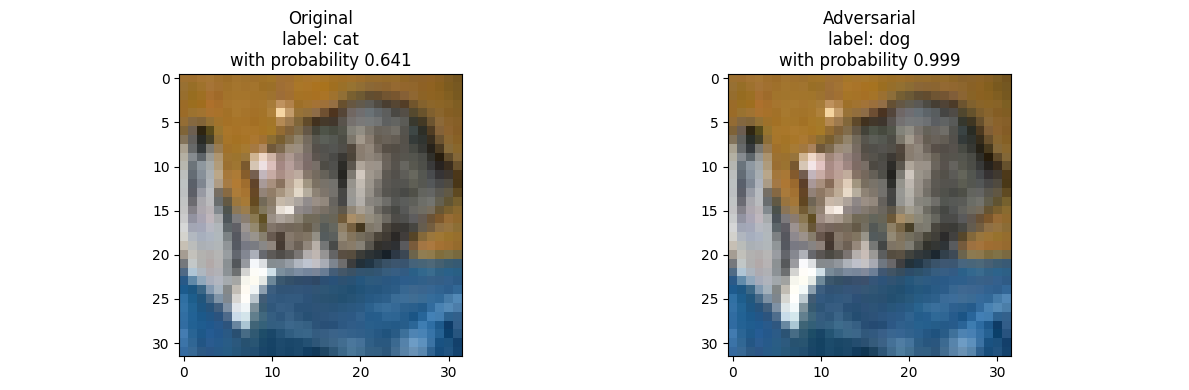

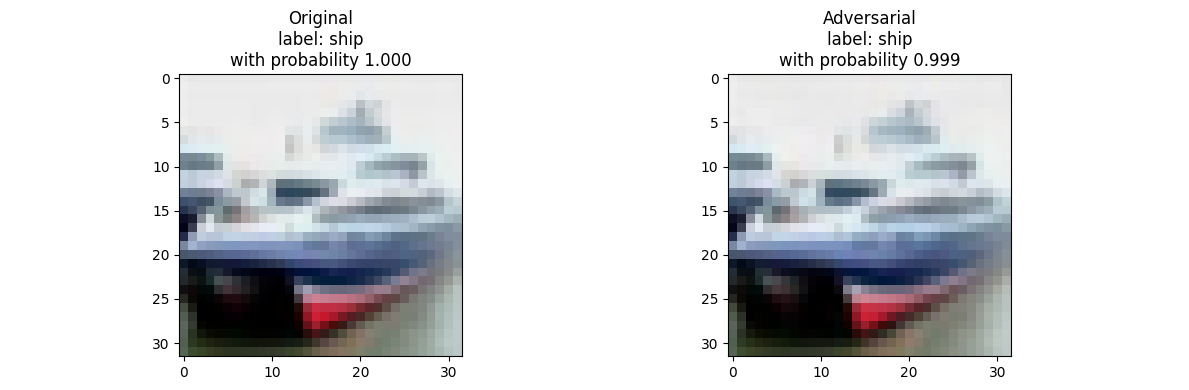

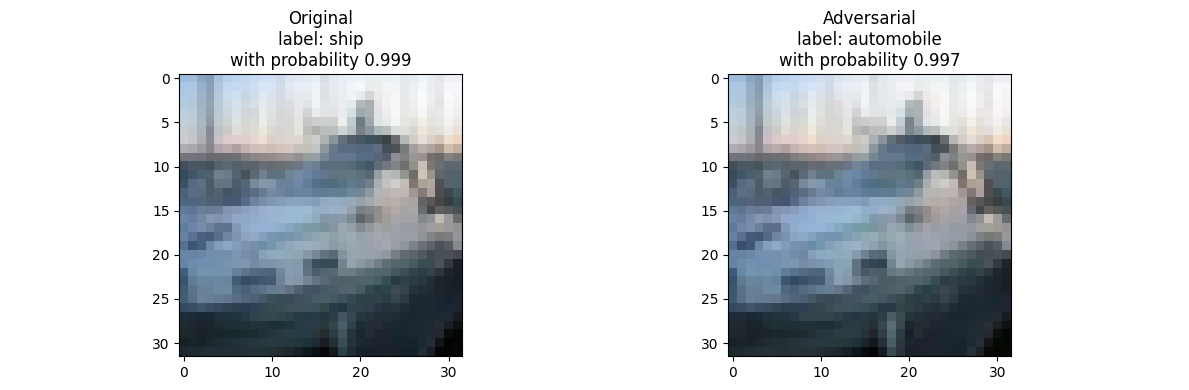

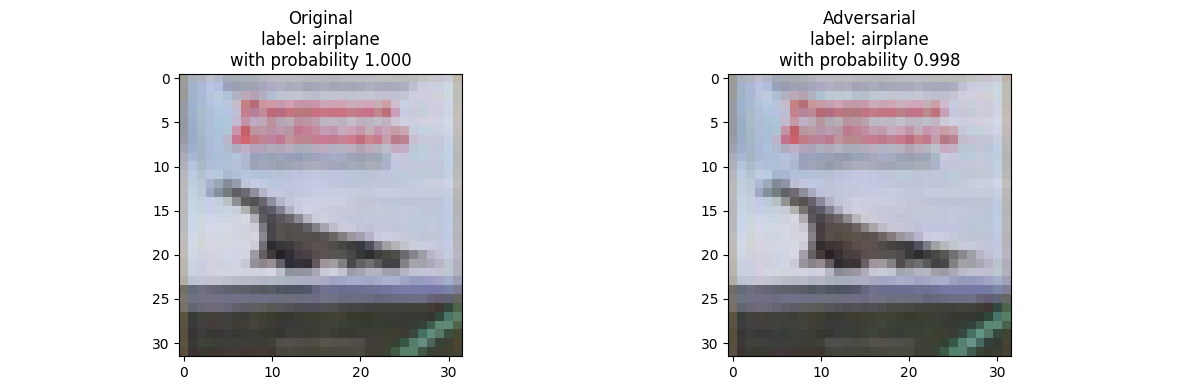

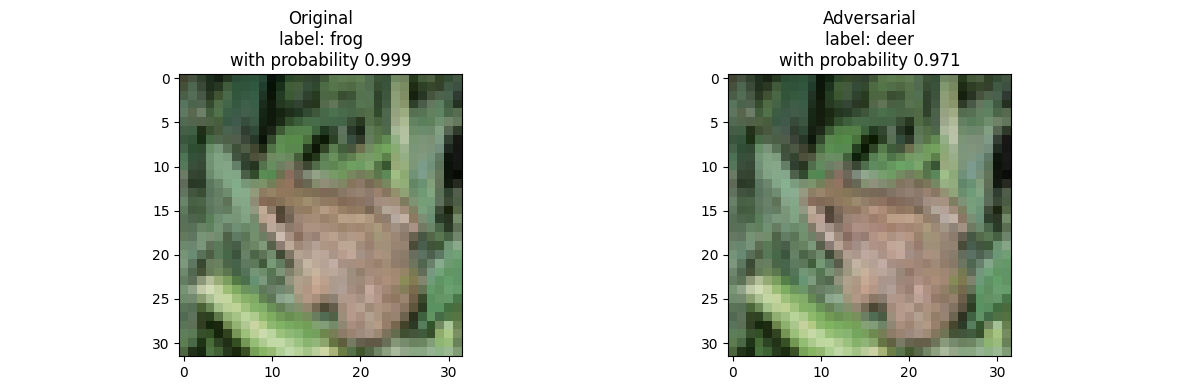

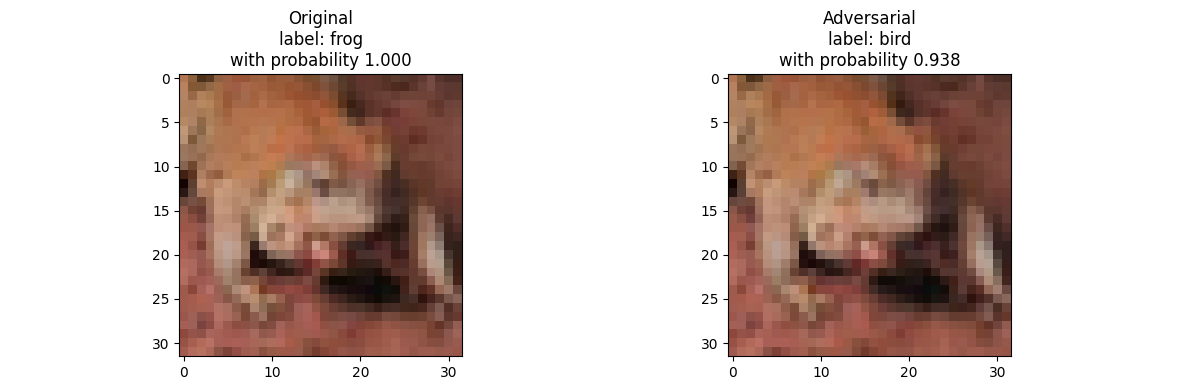

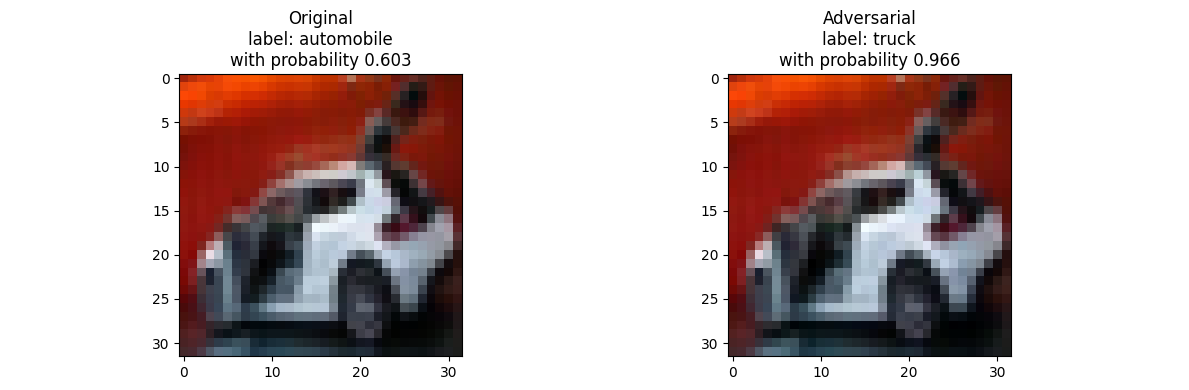

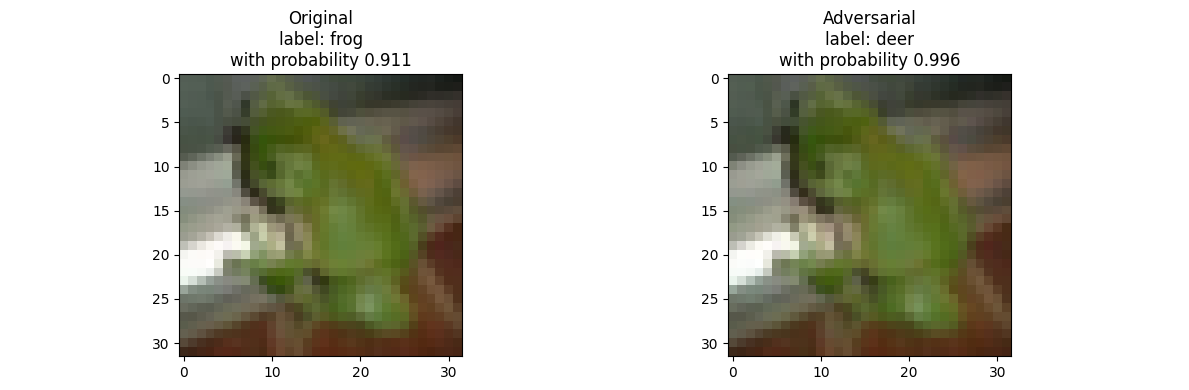

In [43]:
model = tf.keras.models.load_model(get_checkpoint_path("resnet_18v2_adversarial"))
model.compile(metrics=['accuracy'])
pgd_20 = PGDAttack(model, params=attack_params)
test_ds_attacked = test_ds.map(lambda x, y: (pgd_20.generate(x, y), y))

clean_eval = model.evaluate(test_ds)
adv_eval = model.evaluate(test_ds_attacked)

plots = AdversarialPlots(pgd_20, labels)
x, y = test_ds.take(1).get_single_element()
plots.generate_and_show_adversarial_batch(x, y)

Visualizing adversarial examples on single batch from train dataset and evaluating trained model on test dataset

79/79 ━━━━━━━━━━━━━━━━━━━━ 4s 22ms/step - accuracy: 0.8446 - loss: 0.4788
79/79 ━━━━━━━━━━━━━━━━━━━━ 289s 4s/step - accuracy: 0.5598 - loss: 1.2085


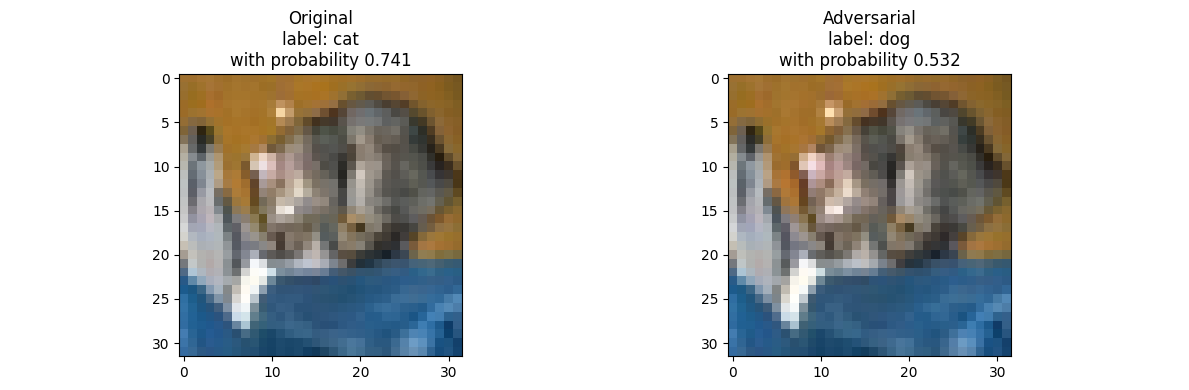

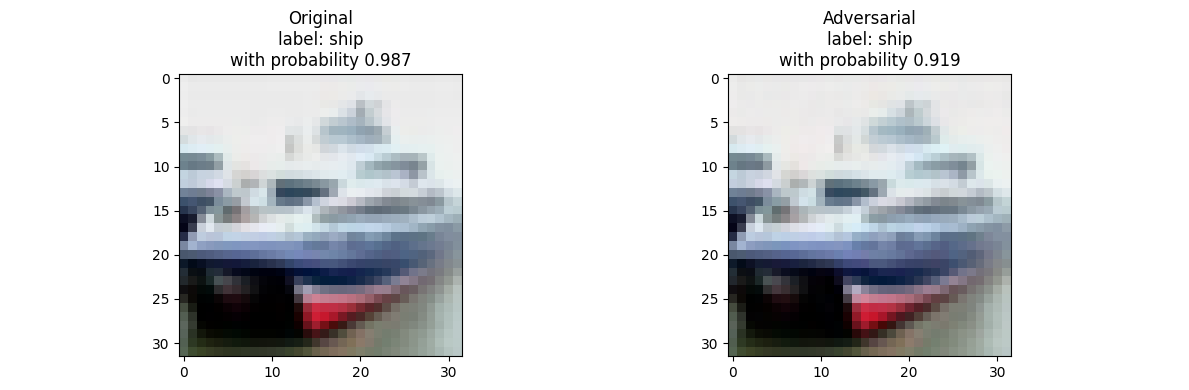

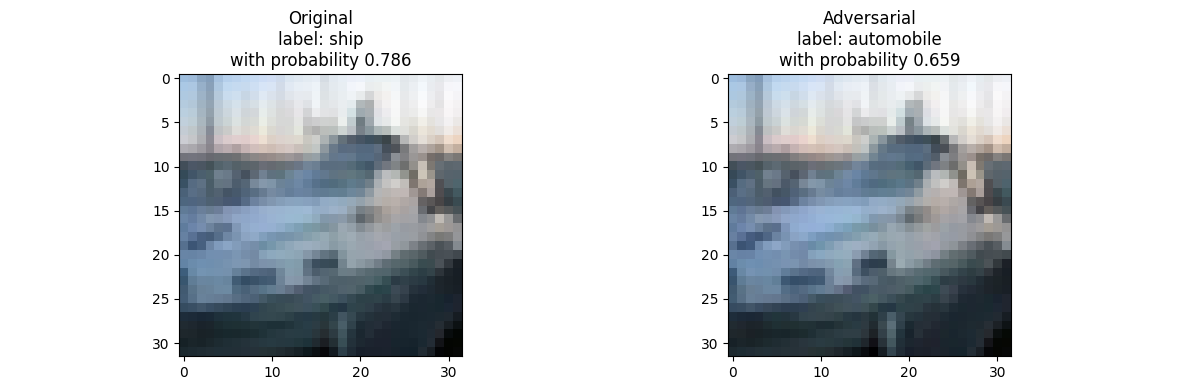

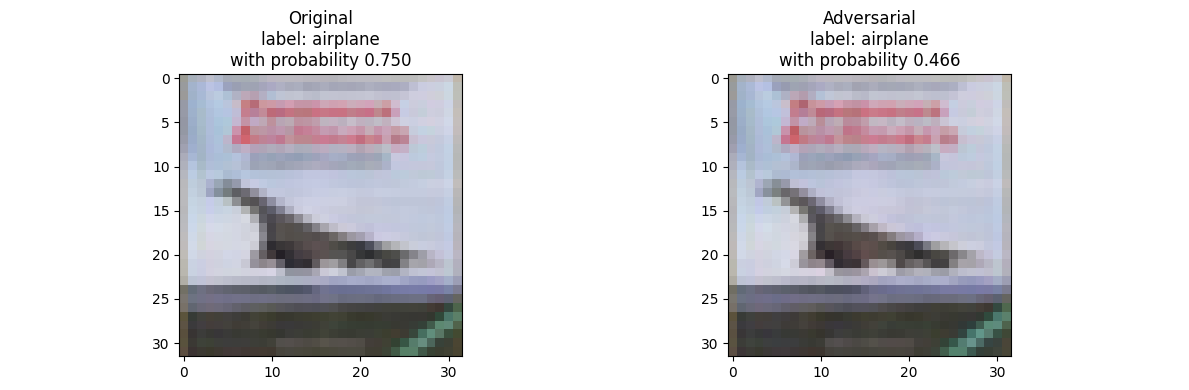

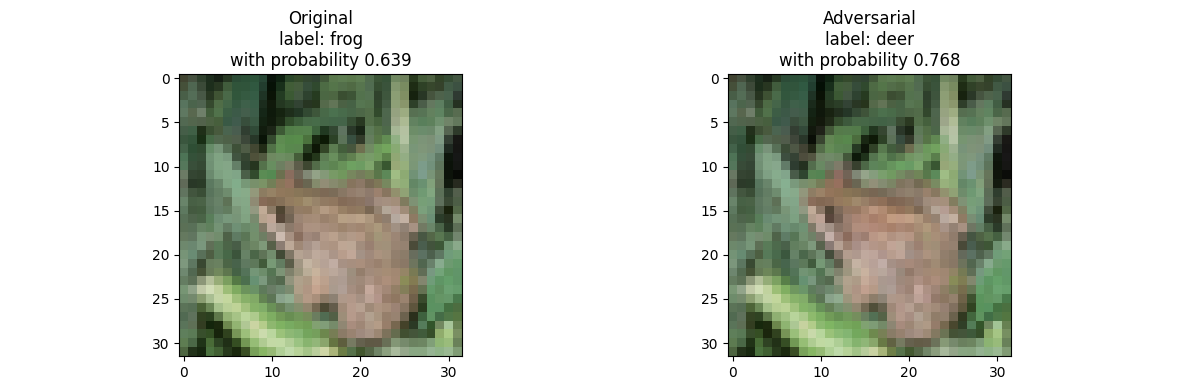

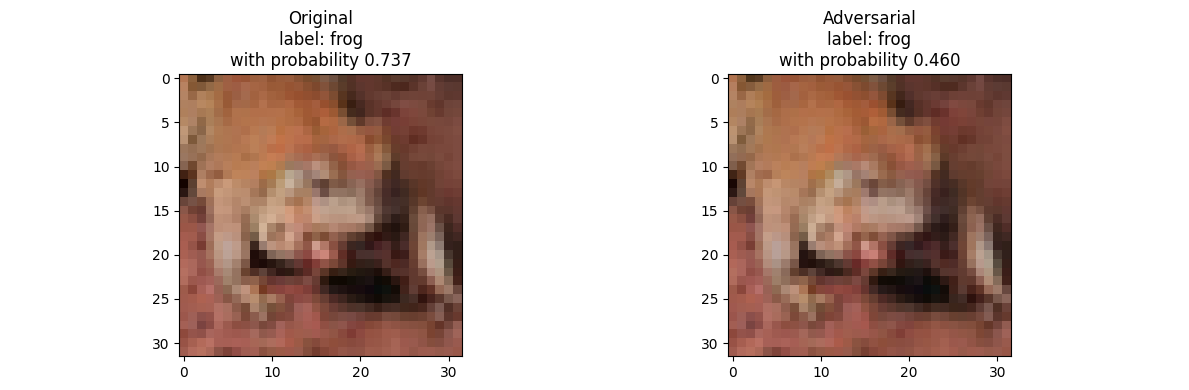

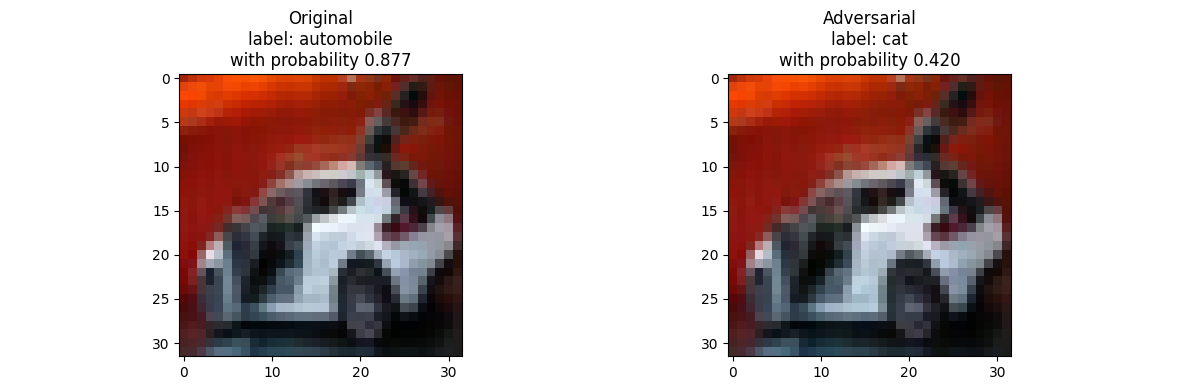

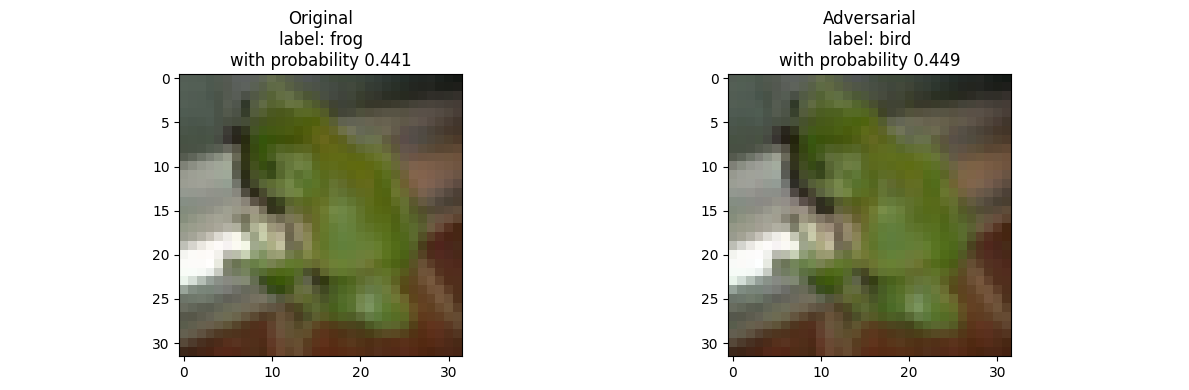

In [42]:
model = tf.keras.models.load_model(get_checkpoint_path("resnet_18v2_awp"))
model.compile(metrics=['accuracy'])
pgd_20 = PGDAttack(model, params=attack_params)
test_ds_attacked = test_ds.map(lambda x, y: (pgd_20.generate(x, y), y))

clean_eval = model.evaluate(test_ds)
adv_eval = model.evaluate(test_ds_attacked)

plots = AdversarialPlots(pgd_20, labels)
x, y = test_ds.take(1).get_single_element()
plots.generate_and_show_adversarial_batch(x, y)